<a href="https://colab.research.google.com/github/gustavocravo/Analise-de-Dados/blob/main/Bridge%26CO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Análise de Desempenho de Filiais - Março 2025

## 🎯 Objetivo
Construir uma solução automatizada para consolidar dados de vendas de múltiplas filiais, padronizar informações inconsistentes e gerar insights quantitativos e qualitativos para apoio à tomada de decisão.


## 🔧 Etapas da solução
1. Coleta automática de preços de referência via web scraping
2. Tratamento e normalização dos dados de vendas
3. Consolidação dos dados em uma única base
4. Estimativa de volume vendido
5. Análise de e-mails com IA
6. Geração de outputs finais

## 🧠 Visão de negócio
A solução permite que a sede:
- Compare desempenho entre filiais
- Identifique problemas operacionais rapidamente
- Tome decisões baseadas em dados estruturados

In [ ]:
import pandas as pd

In [ ]:
import requests

In [ ]:
from bs4 import BeautifulSoup

In [ ]:
import matplotlib.pyplot as plt


## 🌐 Coleta de preços de referência (RPA)

Para estimar o volume vendido por produto, é necessário obter o preço médio nacional.

Essa etapa é automatizada via requisição HTTP, sem צורך de interação manual, garantindo escalabilidade do processo.

In [ ]:
#Extraindo a tabela de preços médios por produto
url = "https://bridgenoc.github.io/case-postos/precos_marco2025.html"
response = requests.get(url)

In [ ]:
soup = BeautifulSoup(response.text, "html.parser")
table = soup.find("table")

In [ ]:
#Criando um DataFrame para a tabela de preços
df_precos = pd.read_html(str(table))[0]

/tmp/ipykernel_4904/3231973908.py:2: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df_precos = pd.read_html(str(table))[0]


In [ ]:
from io import StringIO

df_precos = pd.read_html(StringIO(str(table)))[0]

In [ ]:
response = requests.get(url)
response.raise_for_status()

# Extração e Tratamento de Dados

## 🧹 Tratamento e normalização dos dados

Os dados de entrada apresentam inconsistências nos nomes dos produtos entre filiais.

Exemplo:
- "GC"
- "Gas. Comum"
- "Gasolina Comun"

Para garantir consistência na análise, foi criado um mapeamento para padronizar os nomes em:
- Gasolina Comum
- Etanol
- Diesel S10

In [ ]:
from google.colab import drive
import pandas as pd
import glob

drive.mount('/content/drive')
caminho = '/content/drive/MyDrive/'

todos_arquivos = glob.glob(caminho + "vendas_F00*_marco2025.csv")

# Para ler e juntar tudo em um único DataFrame
lista_df = [pd.read_csv(f) for f in todos_arquivos]
df_final = pd.concat(lista_df, ignore_index=True)

print(f"Arquivos importados: {len(todos_arquivos)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Arquivos importados: 5


In [ ]:
#Criando DataFrames para cada arquivo de vendas
df_vendas01 = pd.read_csv(caminho + 'vendas_F001_marco2025.csv')
df_vendas02 = pd.read_csv(caminho + 'vendas_F002_marco2025.csv')
df_vendas03 = pd.read_csv(caminho + 'vendas_F003_marco2025.csv')
df_vendas04 = pd.read_csv(caminho + 'vendas_F004_marco2025.csv')
df_vendas05 = pd.read_csv(caminho + 'vendas_F005_marco2025.csv')

print("Arquivos lidos separadamente com sucesso!")

Arquivos lidos separadamente com sucesso!


In [ ]:
#Adicionando os campos de 'filial_id' e 'filial_nome' correspondente em cada arquivo
df_vendas01["filial_id"] = 1
df_vendas01["filial_nome"] = "f001"

df_vendas02["filial_id"] = 2
df_vendas02["filial_nome"] = "f002"

df_vendas03["filial_id"] = 3
df_vendas03["filial_nome"] = "f003"

df_vendas04["filial_id"] = 4
df_vendas04["filial_nome"] = "f004"

df_vendas05["filial_id"] = 5
df_vendas05["filial_nome"] = "f005"

Padronização de Produtos (Limpeza de Dados)

In [ ]:
#Analisando quais são os valores unicos do campo produto
valores_unicos = df_vendas01['produto'].unique()
print(valores_unicos)

valores_unicos = df_vendas02['produto'].unique()
print(valores_unicos)

valores_unicos = df_vendas03['produto'].unique()
print(valores_unicos)

valores_unicos = df_vendas04['produto'].unique()
print(valores_unicos)

valores_unicos = df_vendas05['produto'].unique()
print(valores_unicos)

['Gasolina Comum' 'Etanol' 'Diesel S10']
['Gas. Comum' 'Etanol Hidratado' 'Diesel S-10']
['Gasolina Comun' 'Etanol' 'Diesel S10 Aditivado']
['GC' 'Etanol Comum' 'DSL S10']
['Gasolina C' 'Etanol Hid.' 'Diesel S-10']


Os nomes dos produtos apresentam variações entre as filiais (ex: 'GC' vs 'Gasolina Comum'). Abaixo, criei um mapeamento para unificar esses termos e garantir a precisão dos cálculos de volume.

In [ ]:
mapa_produtos = {
    "Gasolina Comum": "Gasolina Comum",
    "Gas. Comum": "Gasolina Comum",
    "GC": "Gasolina Comum",
    "Gasolina Comun": "Gasolina Comum",
    "Gasolina C": "Gasolina Comum",

    "Etanol": "Etanol",
    "Etanol Hidratado": "Etanol",
    "Etanol Comum": "Etanol",
    "Etanol Hid.": "Etanol",

    "Diesel S10": "Diesel S10",
    "Diesel S-10": "Diesel S10",
    "Diesel S10 Aditivado": "Diesel S10",
    "DSL S10": "Diesel S10"
}

In [ ]:
print(df_vendas01.head())

         data         produto  valor_total_brl  filial_id filial_nome
0  2025-03-01  Gasolina Comum             3115          1        f001
1  2025-03-03  Gasolina Comum             3331          1        f001
2  2025-03-04  Gasolina Comum             3208          1        f001
3  2025-03-05  Gasolina Comum             3423          1        f001
4  2025-03-06  Gasolina Comum             3300          1        f001


✅ Resultado:
Todos os produtos foram padronizados com sucesso, sem valores nulos após a normalização.

## 🔗 Consolidação dos dados

Após a padronização, os dados de todas as filiais foram unificados em uma única base para permitir análises comparativas.

In [ ]:
#Criando DataFrame para juntar todas as filiais
arquivos = [
    caminho + 'vendas_F001_marco2025.csv',
    caminho + 'vendas_F002_marco2025.csv',
    caminho + 'vendas_F003_marco2025.csv',
    caminho + 'vendas_F004_marco2025.csv',
    caminho + 'vendas_F005_marco2025.csv'
]

dfs = []

for i, arq in enumerate(arquivos):
    df = pd.read_csv(arq)

    df["filial_id"] = i + 1
    df["filial_nome"] = f"f00{i+1}"

    dfs.append(df)

df_vendas = pd.concat(dfs, ignore_index=True)

In [ ]:
df_vendas["produto_canonico"] = df_vendas["produto"].map(mapa_produtos)

In [ ]:
#Retirando a coluna "produto" do DataFrame e organizando a ordem das colunas
df_vendas.drop(columns=["produto"], inplace=True)
df_vendas = df_vendas[["data", "filial_id", "filial_nome", "produto_canonico", "valor_total_brl"]]

In [ ]:
print(df_vendas.head())

         data  filial_id filial_nome produto_canonico  valor_total_brl
0  2025-03-01          1        f001   Gasolina Comum             3115
1  2025-03-03          1        f001   Gasolina Comum             3331
2  2025-03-04          1        f001   Gasolina Comum             3208
3  2025-03-05          1        f001   Gasolina Comum             3423
4  2025-03-06          1        f001   Gasolina Comum             3300


In [ ]:
print(df_vendas[df_vendas["produto_canonico"].isna()])

Empty DataFrame
Columns: [data, filial_id, filial_nome, produto_canonico, valor_total_brl]
Index: []


In [ ]:
print(df_vendas.head())

         data  filial_id filial_nome produto_canonico  valor_total_brl
0  2025-03-01          1        f001   Gasolina Comum             3115
1  2025-03-03          1        f001   Gasolina Comum             3331
2  2025-03-04          1        f001   Gasolina Comum             3208
3  2025-03-05          1        f001   Gasolina Comum             3423
4  2025-03-06          1        f001   Gasolina Comum             3300


In [ ]:
print(df_precos.head())

          produto  preco_medio_litro_brl unidade
0  Gasolina Comum                   6.29   litro
1          Etanol                   4.11   litro
2      Diesel S10                   6.54   litro


In [ ]:
#Mudando nome da coluna "produto"
df_precos.rename(columns={"produto": "produto_canonico"}, inplace=True)

In [ ]:
#Fazendo merge entre as colunas
df_vendas = df_vendas.merge(
    df_precos,
    on="produto_canonico",
    how="left"
)

In [ ]:
print(df_vendas[df_vendas["preco_medio_litro_brl"].isna()])

Empty DataFrame
Columns: [data, filial_id, filial_nome, produto_canonico, valor_total_brl, preco_medio_litro_brl, unidade]
Index: []


In [ ]:
#Verificando os valores unicos da coluna produto_canonico nos DataFrames
print(df_vendas["produto_canonico"].unique())
print(df_precos["produto_canonico"].unique())

['Gasolina Comum' 'Etanol' 'Diesel S10']
['Gasolina Comum' 'Etanol' 'Diesel S10']


📊 Resultado:
Base consolidada contendo todas as filiais, com estrutura padronizada.

## 📈 Estimativa de volume vendido

O volume foi estimado com base na fórmula:

volume = faturamento ÷ preço médio

Essa métrica permite uma análise mais próxima da operação real das filiais.

In [ ]:
#Calculo de volume estimado
df_vendas["volume_estimado_litros"] = (
    df_vendas["valor_total_brl"] / df_vendas["preco_medio_litro_brl"]
)

In [ ]:
print(df_vendas.head())

         data  filial_id filial_nome produto_canonico  valor_total_brl  \
0  2025-03-01          1        f001   Gasolina Comum             3115   
1  2025-03-03          1        f001   Gasolina Comum             3331   
2  2025-03-04          1        f001   Gasolina Comum             3208   
3  2025-03-05          1        f001   Gasolina Comum             3423   
4  2025-03-06          1        f001   Gasolina Comum             3300   

   preco_medio_litro_brl unidade  volume_estimado_litros  
0                   6.29   litro              495.230525  
1                   6.29   litro              529.570747  
2                   6.29   litro              510.015898  
3                   6.29   litro              544.197138  
4                   6.29   litro              524.642289  


In [ ]:
df_vendas.to_csv("vendas_consolidadas_marco2025.csv", index=False)

📊 Resultado:
Nova coluna adicionada com o volume estimado em litros.

Análise Diária de Vendas

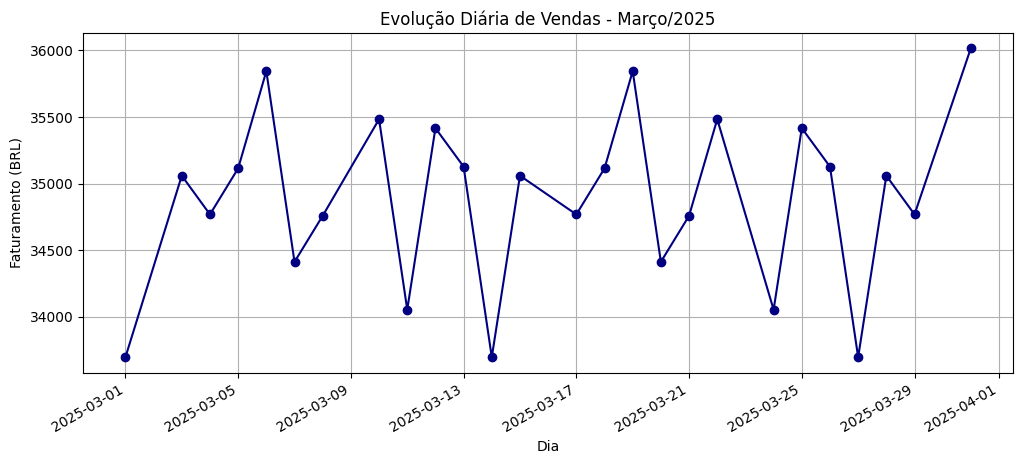

In [ ]:
df_vendas['data'] = pd.to_datetime(df_vendas['data'])

vendas_diarias = df_vendas.groupby('data')['valor_total_brl'].sum()

plt.figure(figsize=(12, 5))
vendas_diarias.plot(kind='line', marker='o', color='navy')
plt.title('Evolução Diária de Vendas - Março/2025')
plt.xlabel('Dia')
plt.ylabel('Faturamento (BRL)')
plt.grid(True)
plt.show()

Ranking de desempenho por filial


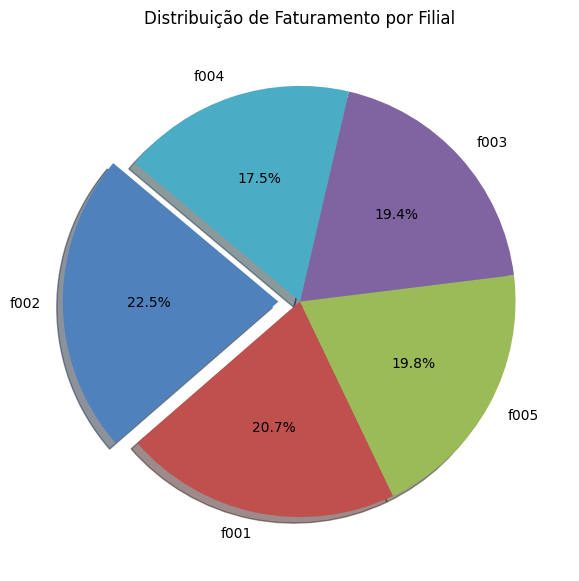

In [ ]:
ranking_filial = (
    df_vendas
    .groupby("filial_nome")["valor_total_brl"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 7))

ranking_filial.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    shadow=True,
    colors=['#4F81BD', '#C0504D', '#9BBB59', '#8064A2', '#4BACC6'],
    explode=(0.1, 0, 0, 0, 0)
)

plt.title('Distribuição de Faturamento por Filial')
plt.ylabel('')
plt.show()

Ranking de desempenho por produto

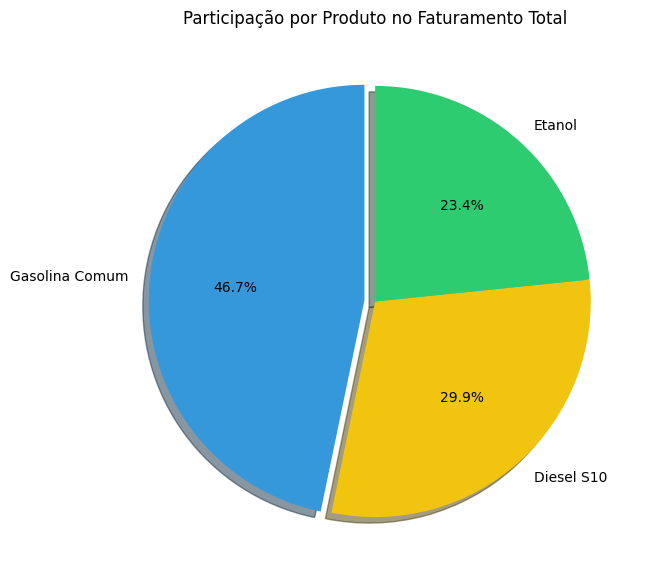

In [ ]:
ranking_produto = (
    df_vendas
    .groupby("produto_canonico")["valor_total_brl"]
    .sum()
    .sort_values(ascending=False)
)
plt.figure(figsize=(10, 7))

cores_combustivel = ['#3498db', '#f1c40f', '#2ecc71']

ranking_produto.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=cores_combustivel,
    explode=(0.05, 0, 0),
    shadow=True
)

plt.title('Participação por Produto no Faturamento Total')
plt.ylabel('')
plt.show()

Análise: A filial F002 lidera as vendas em março, enquanto o produto com maior faturamento foi a Gasolina Comum, representando cerca de 46% do total.


## Importação dos emails

In [ ]:
#Importando os arquivos .txt dos emails das filiais
import pandas as pd
import glob
import os

caminho = '/content/drive/MyDrive/'

padrao_busca = caminho + "email_F00*_marco2025.txt"
todos_arquivos = glob.glob(padrao_busca)

if len(todos_arquivos) == 0:
    print("ERRO: Nenhum arquivo .txt foi encontrado!")
    print("Certifique-se de que a extensão no padrao_busca está como .txt")
else:
    textos_lista = []

    for f in todos_arquivos:
        nome_arquivo = os.path.basename(f)

        with open(f, 'r', encoding='utf-8') as arquivo:
            conteudo = arquivo.read()

            textos_lista.append({
                'nome_do_arquivo': nome_arquivo,
                'conteudo_do_email': conteudo
            })

    df_emails = pd.DataFrame(textos_lista)

    print(f"Sucesso! {len(todos_arquivos)} arquivos de texto importados.")
    display(df_emails.head())

Sucesso! 5 arquivos de texto importados.


,nome_do_arquivo,conteudo_do_email
0,email_F001_marco2025.txt,De: carlos.mendes@postobandeirantes.com.br\nPa...
1,email_F002_marco2025.txt,De: fernanda.lima@autopostocentral.com.br\nPar...
2,email_F003_marco2025.txt,De: roberto.alves@postosaojao.com.br\nPara: re...
3,email_F004_marco2025.txt,De: anapaula.ferreira@ipirangaexpress.com.br\n...
4,email_F005_marco2025.txt,De: marcos.souza@postolitoralnorte.com.br\nPar...


In [ ]:
import os

arquivos_emails = [
    caminho + 'email_F001_marco2025.txt',
    caminho + 'email_F002_marco2025.txt',
    caminho + 'email_F003_marco2025.txt',
    caminho + 'email_F004_marco2025.txt',
    caminho + 'email_F005_marco2025.txt'
]

emails_dict = {}

for arq in arquivos_emails:
    with open(arq, "r", encoding="utf-8") as f:
        filial = arq.split("_")[1].replace(".txt", "")
        emails_dict[filial] = f.read()

## 🧠 Análise de e-mails com IA

Os e-mails dos gerentes contêm informações importantes, mas estão em formato não estruturado.

Foi utilizada uma API de IA para transformar esses dados em um formato estruturado contendo:
- Resumo
- Destaques
- Alertas
- Sentimento geral

In [ ]:
#Instalando IA
!pip install google-generativeai

In [ ]:
#Importando e configurando a API
import google.generativeai as genai
from google.colab import userdata

genai.configure(api_key=userdata.get("KEY"))

#for model in genai.list_models():
    #print(model.name)
model = genai.GenerativeModel("models/gemini-3-flash-preview", generation_config={"response_mime_type": "application/json"})

In [ ]:
#Criando prompt para rodar API e gerar as json
import json
import re

def resumir_email(texto):
    prompt = f"""
    Você é um analista de dados.
    Analise o email abaixo e retorne APENAS um JSON válido no formato:
    {{
      "resumo": "2 a 3 frases sintetizando o relato",
      "destaques": ["ponto 1", "ponto 2", "ponto 3"],
      "alertas": ["problema 1", "problema 2"],
      "sentimento_geral": "positivo, neutro ou negativo"
    }}
    Email:
    {texto}
    """

    response = model.generate_content(prompt)

    texto_limpo = re.sub(r'```json|```', '', response.text).strip()

    try:
        return json.loads(texto_limpo)
    except Exception as e:
        print(f"Erro ao decodificar JSON: {e}")
        return {
            "resumo": "Erro na análise",
            "destaques": [],
            "alertas": ["Erro de processamento"],
            "sentimento_geral": "neutro"
        }

In [ ]:
import time

resultados = []

for filial, texto in emails_dict.items():
    print(f"Analisando e-mail da {filial}...")

    dados = resumir_email(texto)

    resultados.append({
        "filial_id": int(filial.replace("F", "")),
        "filial_nome": filial,
        "resumo": dados["resumo"],
        "alertas": ", ".join(dados["alertas"]),
        "sentimento_geral": dados["sentimento_geral"]
    })

    time.sleep(30)

print("\nTodos os e-mails foram processados com sucesso!")

Analisando e-mail da F001...
Analisando e-mail da F002...
Analisando e-mail da F003...
Analisando e-mail da F004...
Analisando e-mail da F005...

Todos os e-mails foram processados com sucesso!


In [ ]:
#Criando DataFrame para armazenar o resumo de cada filial
df_resumo = pd.DataFrame(resultados)
print(df_resumo)

   filial_id filial_nome                                             resumo  \
0          1        F001  O relatório de março de 2025 do Posto Bandeira...   
1          2        F002  O Auto Posto Central apresentou um crescimento...   
2          3        F003  O relatório de março do Posto São João indica ...   
3          4        F004  O relatório de março de 2025 indica um mês de ...   
4          5        F005  O Posto Litoral Norte registrou em março de 20...   

                                             alertas sentimento_geral  
0  Indisponibilidade temporária da bomba 3 para m...         positivo  
1                                                            positivo  
2  Queda leve no volume de vendas em relação ao m...           neutro  
3  Atraso na entrega por parte do fornecedor, Red...           neutro  
4  Desempenho modesto nas vendas de etanol, Depen...         positivo  


✅ Resultado:
Os e-mails foram convertidos em dados estruturados, permitindo análise rápida pela sede.

#Gerando arquivos finais

In [ ]:
#Transformando os DataFrames em arquivo .csv
df_vendas.to_csv("vendas_consolidadas_marco2025.csv", index=False)
df_resumo.to_csv("resumo_gerentes_marco2025.csv", index=False)

In [ ]:
print(df_vendas.head())

        data  filial_id filial_nome produto_canonico  valor_total_brl  \
0 2025-03-01          1        f001   Gasolina Comum             3115   
1 2025-03-03          1        f001   Gasolina Comum             3331   
2 2025-03-04          1        f001   Gasolina Comum             3208   
3 2025-03-05          1        f001   Gasolina Comum             3423   
4 2025-03-06          1        f001   Gasolina Comum             3300   

   preco_medio_litro_brl unidade  volume_estimado_litros  
0                   6.29   litro              495.230525  
1                   6.29   litro              529.570747  
2                   6.29   litro              510.015898  
3                   6.29   litro              544.197138  
4                   6.29   litro              524.642289  


In [ ]:
print(df_resumo.head())

   filial_id filial_nome                                             resumo  \
0          1        F001  O relatório de março de 2025 do Posto Bandeira...   
1          2        F002  O Auto Posto Central apresentou um crescimento...   
2          3        F003  O relatório de março do Posto São João indica ...   
3          4        F004  O relatório de março de 2025 indica um mês de ...   
4          5        F005  O Posto Litoral Norte registrou em março de 20...   

                                             alertas sentimento_geral  
0  Indisponibilidade temporária da bomba 3 para m...         positivo  
1                                                            positivo  
2  Queda leve no volume de vendas em relação ao m...           neutro  
3  Atraso na entrega por parte do fornecedor, Red...           neutro  
4  Desempenho modesto nas vendas de etanol, Depen...         positivo  


In [ ]:
#Download dos arquivos
from google.colab import files

files.download('vendas_consolidadas_marco2025.csv')
files.download('resumo_gerentes_marco2025.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 📊 Principais insights

- A filial F002 apresentou o maior faturamento no período
- Gasolina Comum representa a maior parcela do faturamento (~46%)
- Algumas filiais apresentaram alertas operacionais relevantes (ex: falhas em bombas, queda de vendas)

💡 Interpretação:
A sede pode priorizar a análise da filial F002 para entender boas práticas e investigar as filiais com alertas para ações corretivas.

## 📦 Outputs gerados

- vendas_consolidadas_marco2025.csv → base unificada com volume estimado
- resumo_gerentes_marco2025.csv → insights estruturados dos e-mails

Esses arquivos estão prontos para consumo pela área de negócio.